In [16]:
# Setup loading csv file in format output by window_sequence_analysis/run_svm_prediction.py
from __future__ import annotations

import re
from dataclasses import dataclass, field
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

plt.style.use("seaborn-v0_8-whitegrid")


def repo_root_from_here() -> Path:
    here = Path.cwd().resolve()
    for path in (here, *here.parents):
        if (path / "window_sequence_analysis").is_dir():
            return path
    return here


ROOT = repo_root_from_here()
PROFILES_CSV = ROOT / "results" / "window_sequence_profiles.csv"

CLUSTER_COL = "single_cell_expression_cluster"
PROFILE_COL = "hyperplane_distance_mean_profile"
DELIMITER_COL = "profile_delimiter"
UNASSIGNED_LABEL = "(unassigned)"

PROFILE_GRID = 200
MAX_OVERLAY_TRACES = 40
CLUSTERS_PER_PAGE = 6
NCOLS = 2
INCLUDE_UNASSIGNED = True
CLUSTER_SUBSTRING: str | None = None
MAX_CLUSTERS: int | None = 12
CLUSTER_RANK_COL = "best_window_p_amp"

print("ROOT:", ROOT)
print("profiles:", PROFILES_CSV)


ROOT: C:\Users\bioin\Documents\Peptide-Anti-microbial-Properties-Prediction
profiles: C:\Users\bioin\Documents\Peptide-Anti-microbial-Properties-Prediction\results\window_sequence_profiles.csv


In [17]:
# load the input csv into an in-memory object to group by cluster


def parse_profile(text: object, delimiter: str = ";") -> np.ndarray:
    parts = str(text).split(delimiter or ";")
    values = np.empty(len(parts), dtype=np.float64)
    for i, part in enumerate(parts):
        token = part.strip()
        if not token or token.lower() == "nan":
            values[i] = np.nan
        else:
            values[i] = float(token)
    return values


def cluster_label(value: object) -> str:
    text = "" if pd.isna(value) else str(value).strip()
    return text or UNASSIGNED_LABEL


def cluster_sort_key(name: str) -> tuple[int, int, str]:
    match = re.match(r"Cluster\s+(\d+)", name)
    if match:
        return (0, int(match.group(1)), name)
    if name == UNASSIGNED_LABEL:
        return (2, 0, name)
    return (1, 0, name)


def short_cluster_label(name: str, max_len: int = 48) -> str:
    text = name[len("Cluster ") :] if name.startswith("Cluster ") else name
    if len(text) <= max_len:
        return text
    return text[: max_len - 3] + "..."


def positive_runs(sigma: np.ndarray) -> list[tuple[int, int]]:
    mask = np.isfinite(sigma) & (sigma > 0)
    if not np.any(mask):
        return []
    padded = np.concatenate(([False], mask, [False]))
    edges = np.diff(padded.astype(np.int8))
    starts = np.flatnonzero(edges == 1)
    ends = np.flatnonzero(edges == -1)
    return list(zip(starts.tolist(), ends.tolist()))


def compute_dngc(sigma: np.ndarray) -> tuple[float, float, int]:
    """DNGC = area under positive σNGC / total aa length of those runs.

    Run length is (X2 - X1) + (X4 - X3) + ... using half-open residue intervals.
    Each residue is a histogram bar of width 1, so area is the sum of positive σNGC.
    """
    runs = positive_runs(sigma)
    if not runs:
        return 0.0, 0.0, 0
    length = sum(end - start for start, end in runs)
    area = float(sum(np.sum(sigma[start:end]) for start, end in runs))
    return area / length, area, length


def interpolate_profile(sigma: np.ndarray, grid: int = PROFILE_GRID) -> np.ndarray:
    finite = np.isfinite(sigma)
    if not np.any(finite):
        return np.full(grid, np.nan, dtype=np.float64)
    x = np.linspace(0.0, 1.0, len(sigma))
    xp = np.linspace(0.0, 1.0, grid)
    filled = np.nan_to_num(sigma, nan=0.0)
    return np.interp(xp, x, filled)


@dataclass
class SequenceProfile:
    id: str
    name: str
    cluster: str
    sigma: np.ndarray
    dngc: float
    positive_area: float
    positive_length: int
    best_window_p_amp: float
    best_window_hyperplane_distance: float

    @property
    def relative_sigma(self) -> np.ndarray:
        return interpolate_profile(self.sigma)


def _mean_finite(values: list[float]) -> float:
    finite = np.asarray(values, dtype=np.float64)
    finite = finite[np.isfinite(finite)]
    return float(np.mean(finite)) if finite.size else float("nan")


@dataclass
class ClusterGroup:
    name: str
    profiles: list[SequenceProfile] = field(default_factory=list)

    @property
    def n(self) -> int:
        return len(self.profiles)

    @property
    def mean_dngc(self) -> float:
        return _mean_finite([item.dngc for item in self.profiles])

    @property
    def mean_best_window_p_amp(self) -> float:
        return _mean_finite([item.best_window_p_amp for item in self.profiles])

    @property
    def mean_best_window_distance(self) -> float:
        return _mean_finite([item.best_window_hyperplane_distance for item in self.profiles])

    @property
    def rank_score(self) -> float:
        if CLUSTER_RANK_COL == "best_window_hyperplane_distance":
            return self.mean_best_window_distance
        return self.mean_best_window_p_amp

    def stacked_relative_sigma(self) -> np.ndarray:
        if not self.profiles:
            return np.empty((0, PROFILE_GRID), dtype=np.float64)
        return np.vstack([item.relative_sigma for item in self.profiles])


def load_profile_table(path: Path) -> pd.DataFrame:
    if not path.is_file():
        raise FileNotFoundError(f"Window profile CSV not found: {path}")
    frame = pd.read_csv(path)
    required = {"id", PROFILE_COL, CLUSTER_COL}
    missing = sorted(required - set(frame.columns))
    if missing:
        raise ValueError(f"Profile CSV missing columns: {missing}")
    return frame


def build_cluster_groups(frame: pd.DataFrame) -> list[ClusterGroup]:
    delimiter = ";"
    if DELIMITER_COL in frame.columns:
        first = frame[DELIMITER_COL].dropna()
        if not first.empty:
            delimiter = str(first.iloc[0]) or ";"

    grouped: dict[str, ClusterGroup] = {}
    for row in frame.itertuples(index=False):
        label = cluster_label(getattr(row, CLUSTER_COL))
        if label == UNASSIGNED_LABEL and not INCLUDE_UNASSIGNED:
            continue
        if CLUSTER_SUBSTRING and CLUSTER_SUBSTRING.casefold() not in label.casefold():
            continue
        sigma = parse_profile(getattr(row, PROFILE_COL), delimiter)
        dngc, area, length = compute_dngc(sigma)
        name = str(getattr(row, "name", "") or "").strip()
        profile = SequenceProfile(
            id=str(getattr(row, "id")),
            name=name,
            cluster=label,
            sigma=sigma,
            dngc=dngc,
            positive_area=area,
            positive_length=length,
            best_window_p_amp=_row_float(row, "best_window_p_amp"),
            best_window_hyperplane_distance=_row_float(row, "best_window_hyperplane_distance"),
        )
        grouped.setdefault(label, ClusterGroup(name=label)).profiles.append(profile)

    groups = sorted(
        grouped.values(),
        key=lambda group: (
            -group.rank_score if np.isfinite(group.rank_score) else float("inf"),
            cluster_sort_key(group.name),
        ),
    )
    if MAX_CLUSTERS is not None:
        groups = groups[: max(0, int(MAX_CLUSTERS))]
    return groups


def _row_float(row: object, column: str) -> float:
    if not hasattr(row, column):
        return float("nan")
    try:
        value = float(getattr(row, column))
    except (TypeError, ValueError):
        return float("nan")
    return value if np.isfinite(value) else float("nan")


profiles_df = load_profile_table(PROFILES_CSV)
clusters = build_cluster_groups(profiles_df)
n_sequences = sum(group.n for group in clusters)
print(f"Loaded {n_sequences:,} sequences in {len(clusters):,} clusters from {PROFILES_CSV.name}")
print(f"Sorted by descending mean {CLUSTER_RANK_COL}")
if clusters:
    top = clusters[0]
    bottom = clusters[-1]
    print(
        f"Highest: {top.name} (n={top.n}, mean {CLUSTER_RANK_COL}={top.rank_score:.3g})"
    )
    print(
        f"Lowest shown: {bottom.name} (n={bottom.n}, mean {CLUSTER_RANK_COL}={bottom.rank_score:.3g})"
    )


Loaded 293 sequences in 12 clusters from window_sequence_profiles.csv
Sorted by descending mean best_window_p_amp
Highest: Cluster 51: Secretory epithelial cells - Mixed function (n=53, mean best_window_p_amp=0.786)
Lowest shown: Cluster 20: Non-specific - Transcription regulation (n=32, mean best_window_p_amp=0.698)


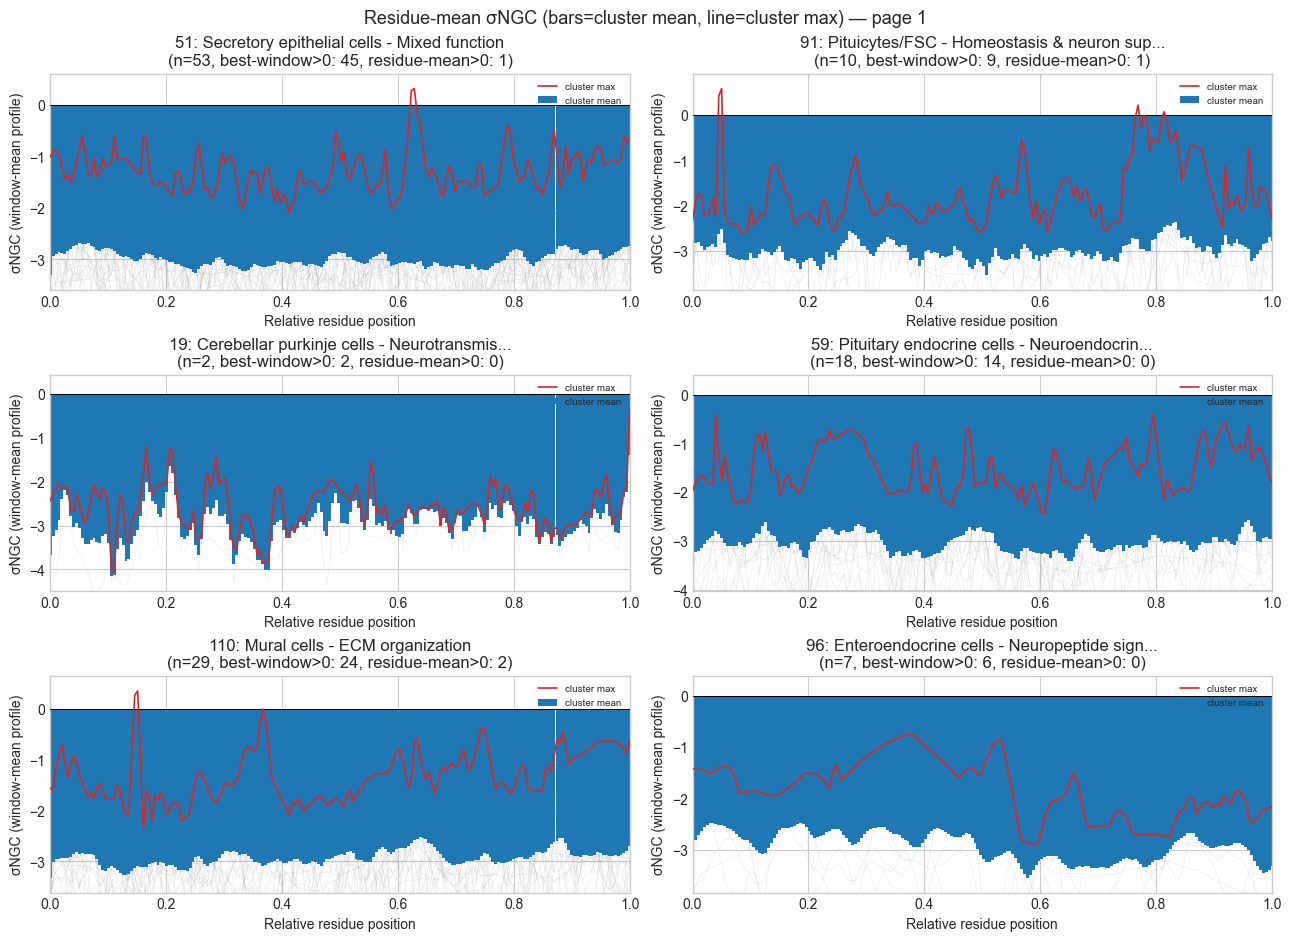

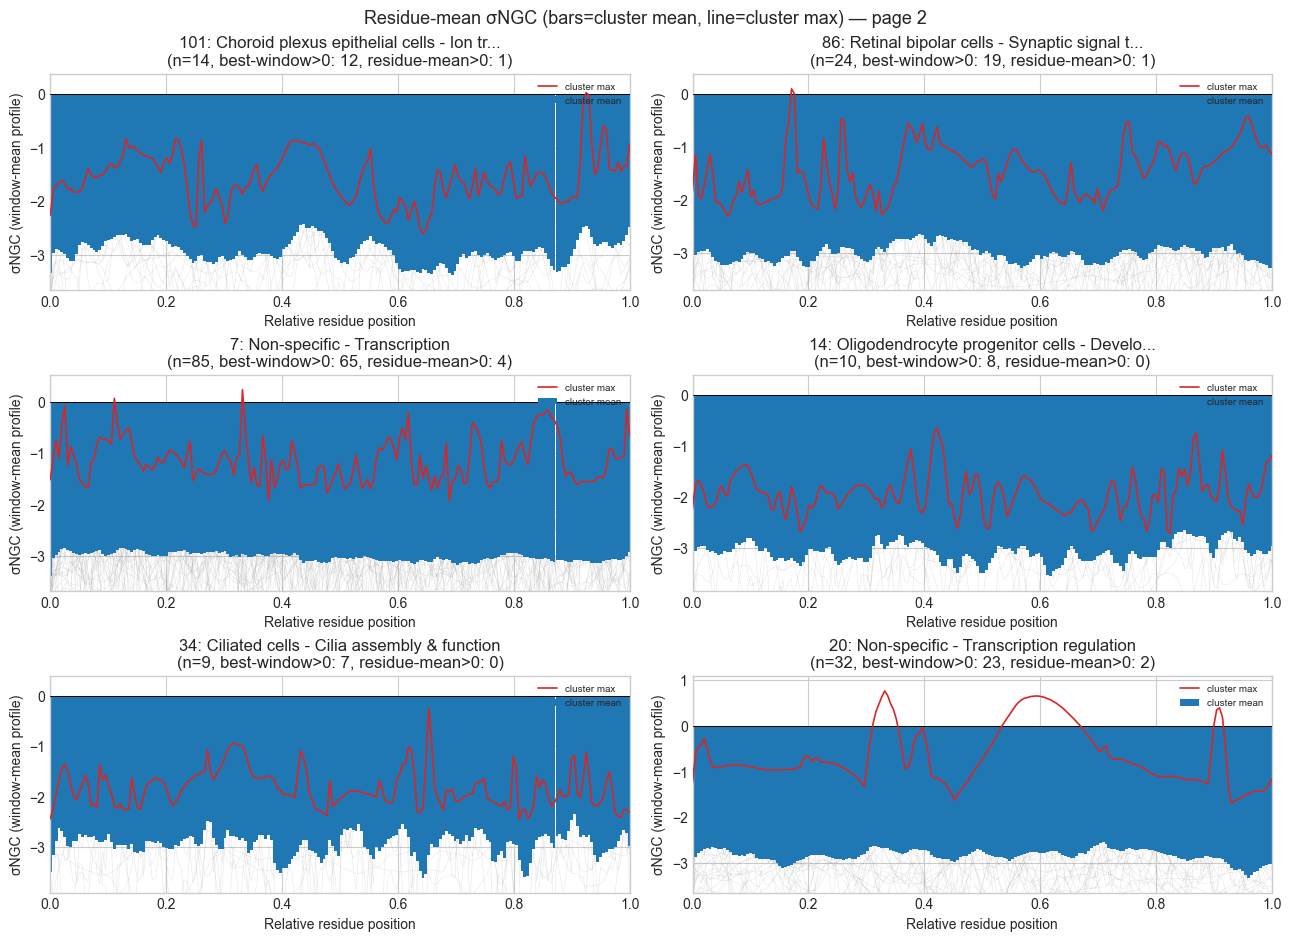

In [18]:
# graph displaying hyperplane distance sigmaNGC histogram over amino acid sequence
# there should be one graph for each unique cluster value in the csv


def _page_slices(n_items: int, per_page: int) -> list[slice]:
    return [slice(start, min(start + per_page, n_items)) for start in range(0, n_items, per_page)]


def _sigma_ylim(mean_sigma: np.ndarray, max_sigma: np.ndarray) -> tuple[float, float]:
    lo = float(np.nanmin(mean_sigma)) if mean_sigma.size else -1.0
    hi = float(np.nanmax(max_sigma)) if max_sigma.size else 1.0
    lo = min(lo, 0.0)
    hi = max(hi, 0.1)
    pad = 0.08 * max(hi - lo, 1.0)
    return (lo - pad, hi + pad)


def draw_sigma_histogram(ax, group: ClusterGroup) -> None:
    x = np.linspace(0.0, 1.0, PROFILE_GRID)
    width = 1.0 / PROFILE_GRID
    stacked = group.stacked_relative_sigma()
    mean_sigma = np.nanmean(stacked, axis=0)
    max_sigma = np.nanmax(stacked, axis=0)
    n_best_pos = sum(item.best_window_hyperplane_distance > 0 for item in group.profiles)
    n_profile_pos = sum(np.nanmax(item.sigma) > 0 for item in group.profiles)

    overlay_n = min(group.n, MAX_OVERLAY_TRACES)
    for row in stacked[:overlay_n]:
        ax.plot(x, row, color="0.55", linewidth=0.4, alpha=0.2, zorder=1)

    ax.bar(x, mean_sigma, width=width, align="center", color="C0", linewidth=0, zorder=2, label="cluster mean")
    ax.plot(x, max_sigma, color="C3", linewidth=1.2, zorder=4, label="cluster max")
    ax.axhline(0.0, color="black", linewidth=0.7, zorder=3)
    ax.set(
        xlim=(0.0, 1.0),
        ylim=_sigma_ylim(mean_sigma, max_sigma),
        xlabel="Relative residue position",
        ylabel="σNGC (window-mean profile)",
        title=(
            f"{short_cluster_label(group.name)}\n"
            f"(n={group.n}, best-window>0: {n_best_pos}, residue-mean>0: {n_profile_pos})"
        ),
    )
    ax.legend(fontsize=7, loc="upper right")


def plot_sigma_by_cluster(groups: list[ClusterGroup]) -> None:
    if not groups:
        print("No clusters to plot.")
        return
    per_page = max(1, CLUSTERS_PER_PAGE)
    ncols = max(1, NCOLS)
    for page, slc in enumerate(_page_slices(len(groups), per_page), start=1):
        batch = groups[slc]
        nrows = int(np.ceil(len(batch) / ncols))
        fig, axes = plt.subplots(
            nrows,
            ncols,
            figsize=(6.4 * ncols, 3.1 * nrows),
            squeeze=False,
            layout="constrained",
        )
        for ax, group in zip(axes.ravel(), batch):
            draw_sigma_histogram(ax, group)
        for ax in axes.ravel()[len(batch) :]:
            ax.set_visible(False)
        fig.suptitle(
            f"Residue-mean σNGC (bars=cluster mean, line=cluster max) — page {page}",
            fontsize=13,
        )
        plt.show()


plot_sigma_by_cluster(clusters)


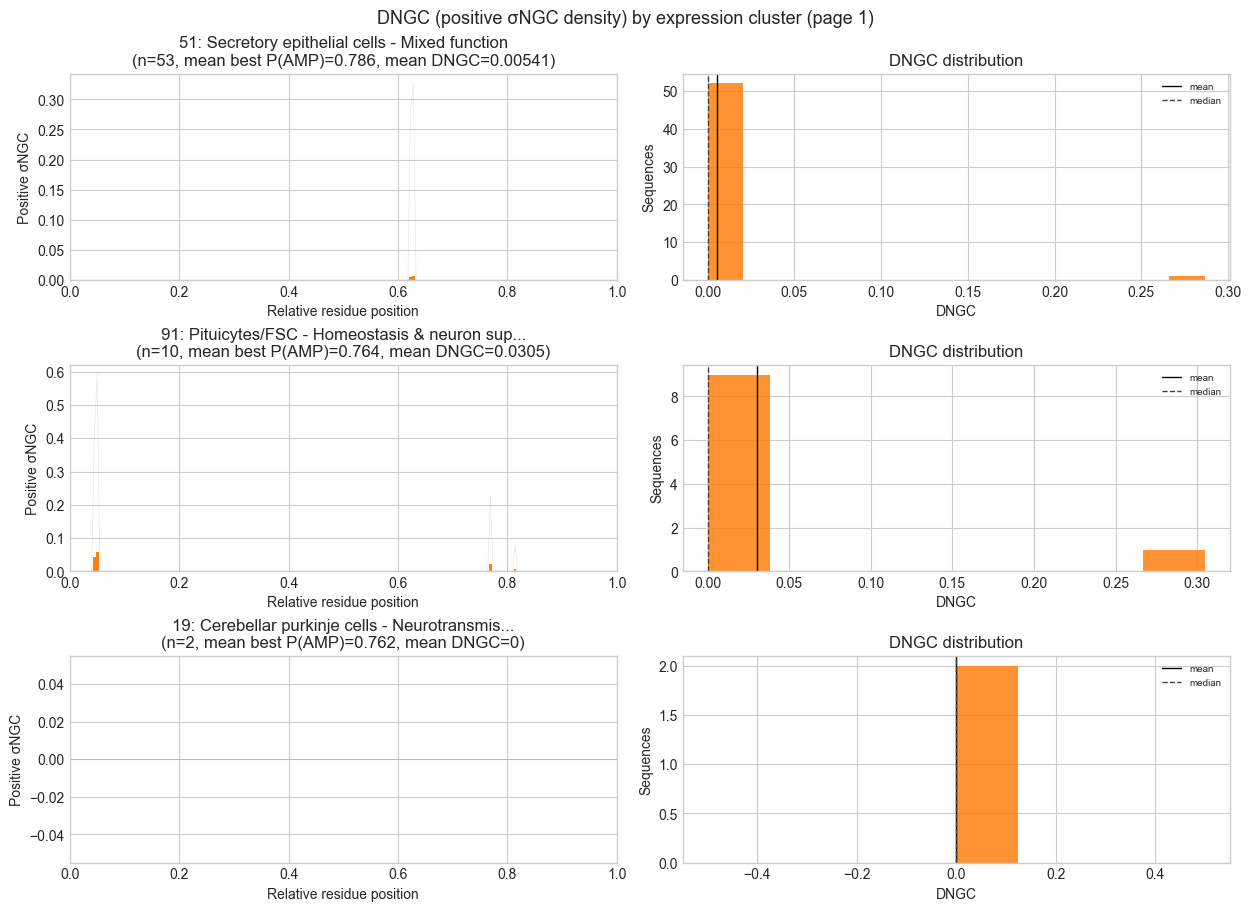

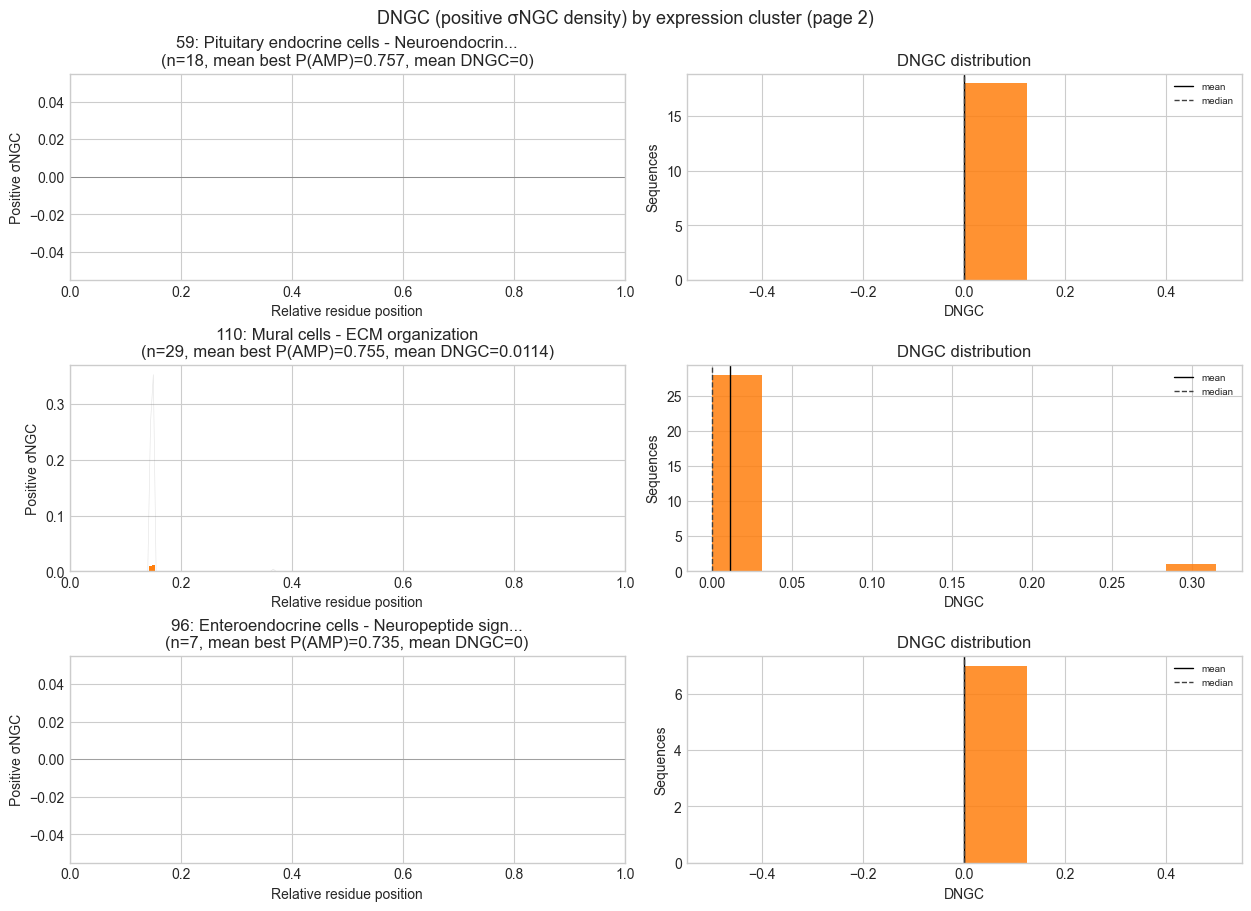

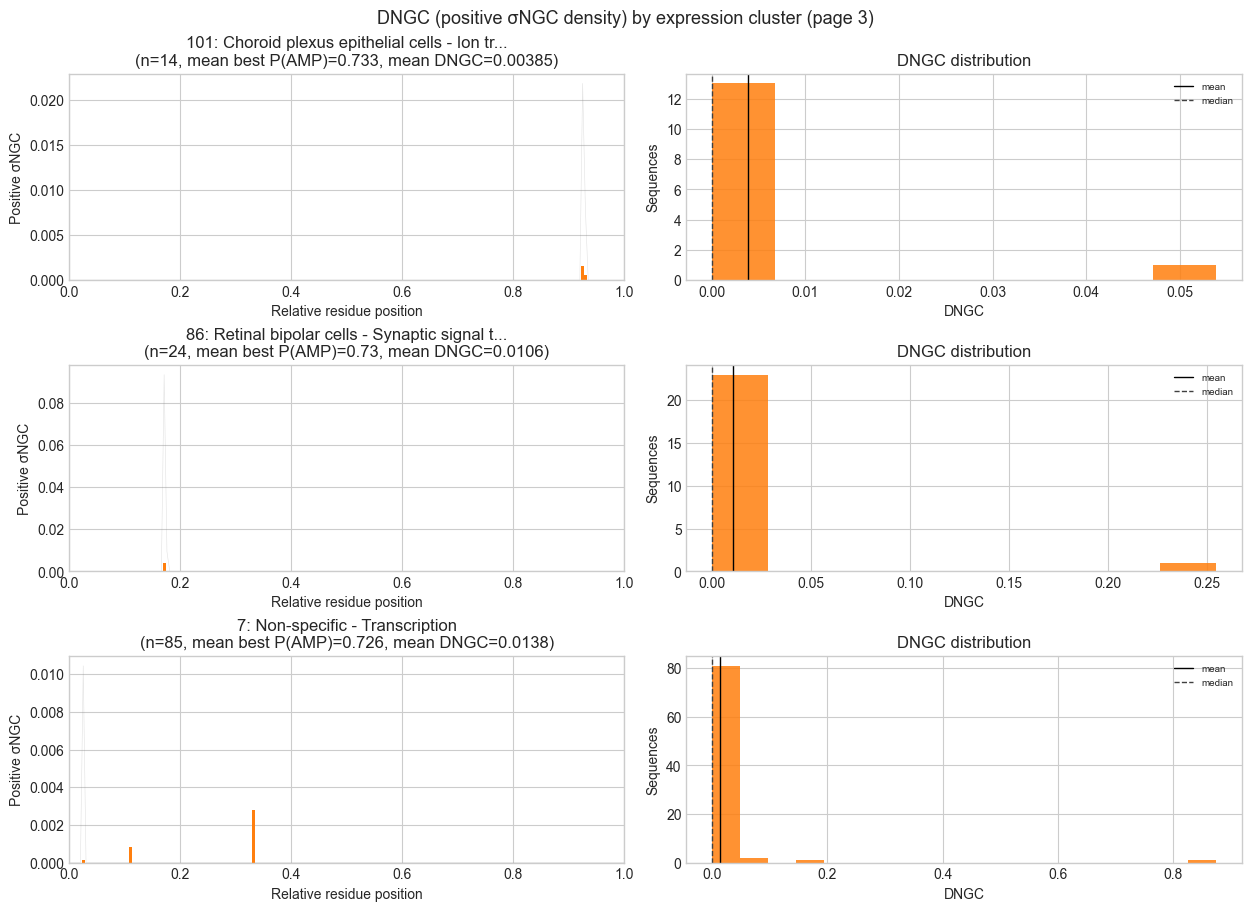

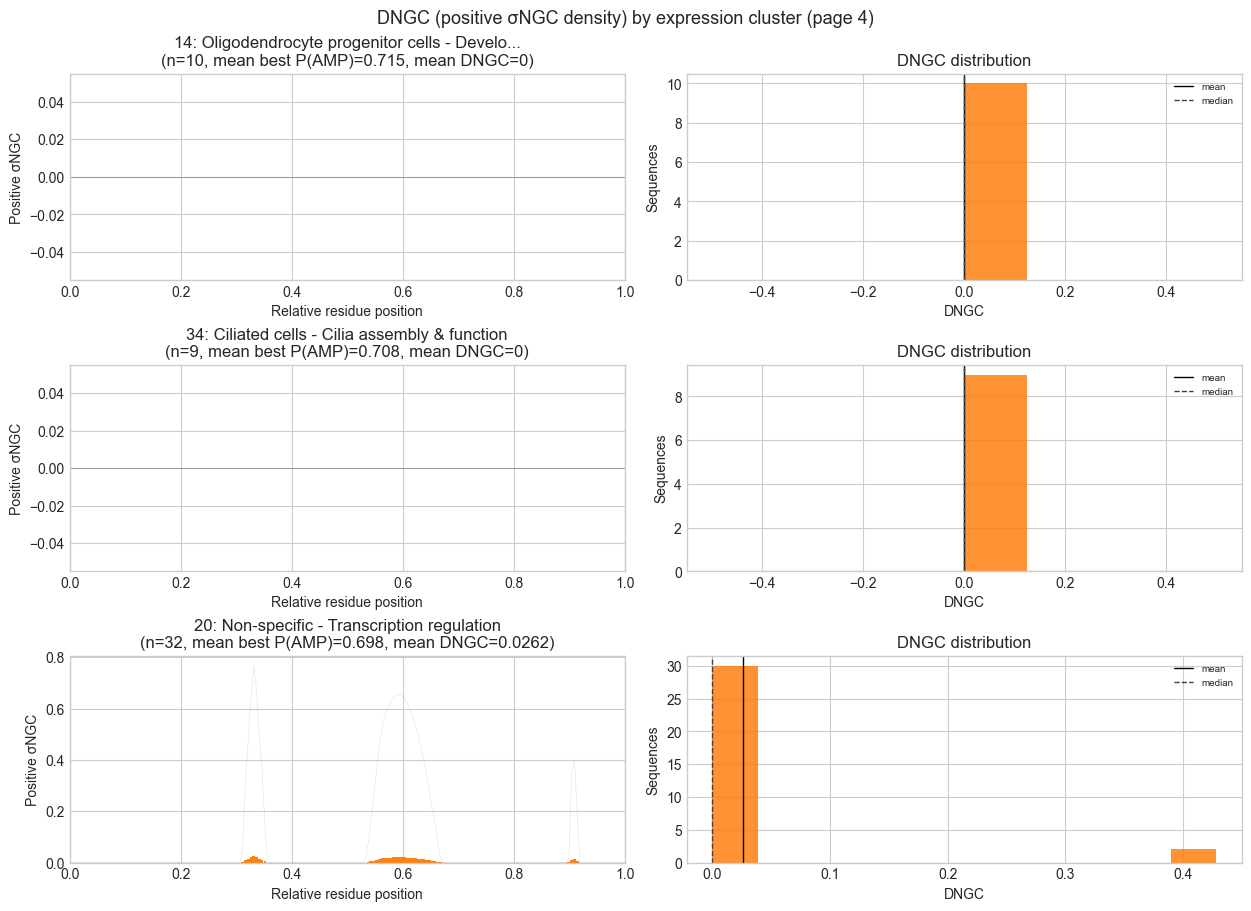

In [19]:
# graph displaying density NGC (DNGC), which is the area under curve of non-zero positive sigmaNGC values
# DNGC = area under the curves/total aa length of non-zero σNGC
# total aa length of non-zero σNGC = (X4-X3)+(X2-X1)
# This graph should be one plot per cluster


def _positive_relative_sigma(item: SequenceProfile) -> np.ndarray:
    positive = item.sigma.copy()
    positive[~(np.isfinite(positive) & (positive > 0))] = 0.0
    return interpolate_profile(positive)


def draw_dngc_plot(ax_curve, ax_hist, group: ClusterGroup) -> None:
    x = np.linspace(0.0, 1.0, PROFILE_GRID)
    width = 1.0 / PROFILE_GRID
    stacked = np.vstack([_positive_relative_sigma(item) for item in group.profiles])
    mean_positive = np.nanmean(stacked, axis=0)
    dngc_values = np.array([item.dngc for item in group.profiles], dtype=np.float64)

    overlay_n = min(group.n, MAX_OVERLAY_TRACES)
    for row in stacked[:overlay_n]:
        ax_curve.plot(x, row, color="0.55", linewidth=0.4, alpha=0.25, zorder=1)
    ax_curve.bar(x, mean_positive, width=width, align="center", color="C1", linewidth=0, zorder=2)
    ax_curve.set(
        xlim=(0.0, 1.0),
        xlabel="Relative residue position",
        ylabel="Positive σNGC",
        title=(
            f"{short_cluster_label(group.name)}\n"
            f"(n={group.n}, mean best P(AMP)={group.mean_best_window_p_amp:.3g}, "
            f"mean DNGC={group.mean_dngc:.3g})"
        ),
    )

    finite = dngc_values[np.isfinite(dngc_values)]
    if finite.size:
        bins = min(24, max(8, int(np.sqrt(finite.size) * 2)))
        ax_hist.hist(finite, bins=bins, color="C1", alpha=0.85, linewidth=0)
        ax_hist.axvline(float(np.mean(finite)), color="black", linewidth=1.0, label="mean")
        ax_hist.axvline(float(np.median(finite)), color="0.25", linestyle="--", linewidth=1.0, label="median")
        ax_hist.legend(fontsize=7, loc="best")
    ax_hist.set(xlabel="DNGC", ylabel="Sequences", title="DNGC distribution")


def plot_dngc_by_cluster(groups: list[ClusterGroup]) -> None:
    if not groups:
        print("No clusters to plot.")
        return
    for page, slc in enumerate(_page_slices(len(groups), max(1, CLUSTERS_PER_PAGE // 2)), start=1):
        batch = groups[slc]
        fig, axes = plt.subplots(
            len(batch),
            2,
            figsize=(12.4, 3.0 * len(batch)),
            squeeze=False,
            layout="constrained",
        )
        for row, group in enumerate(batch):
            draw_dngc_plot(axes[row, 0], axes[row, 1], group)
        fig.suptitle(f"DNGC (positive σNGC density) by expression cluster (page {page})", fontsize=13)
        plt.show()


plot_dngc_by_cluster(clusters)
 

In [20]:
# Per-cluster summary (same order as plots: mean best-window P(AMP) descending)

summary = pd.DataFrame(
    {
        "single_cell_expression_cluster": [group.name for group in clusters],
        "n": [group.n for group in clusters],
        "mean_best_window_p_amp": [group.mean_best_window_p_amp for group in clusters],
        "mean_best_window_distance": [group.mean_best_window_distance for group in clusters],
        "mean_DNGC": [group.mean_dngc for group in clusters],
        "median_DNGC": [
            float(np.median([item.dngc for item in group.profiles])) for group in clusters
        ],
        "frac_positive_sigma": [
            float(np.mean([item.positive_length > 0 for item in group.profiles]))
            for group in clusters
        ],
        "mean_positive_aa": [
            float(np.mean([item.positive_length for item in group.profiles]))
            for group in clusters
        ],
    }
)

print(
    f"Cluster summary ({len(summary)} groups), highest mean {CLUSTER_RANK_COL} first:"
)
display(summary)


Cluster summary (12 groups), highest mean best_window_p_amp first:


,single_cell_expression_cluster,n,mean_best_window_p_amp,mean_best_window_distance,mean_DNGC,median_DNGC,frac_positive_sigma,mean_positive_aa
0,Cluster 51: Secretory epithelial cells - Mixed...,53,0.786220,0.742686,0.005409,0.0,0.018868,0.245283
1,Cluster 91: Pituicytes/FSC - Homeostasis & neu...,10,0.764445,0.752128,0.030483,0.0,0.100000,6.000000
2,Cluster 19: Cerebellar purkinje cells - Neurot...,2,0.762377,0.762796,0.000000,0.0,0.000000,0.000000
3,Cluster 59: Pituitary endocrine cells - Neuroe...,18,0.756515,0.777517,0.000000,0.0,0.000000,0.000000
4,Cluster 110: Mural cells - ECM organization,29,0.754867,0.676549,0.011352,0.0,0.068966,0.586207
5,Cluster 96: Enteroendocrine cells - Neuropepti...,7,0.735111,0.385318,0.000000,0.0,0.000000,0.000000
6,Cluster 101: Choroid plexus epithelial cells -...,14,0.732610,0.657822,0.003852,0.0,0.071429,0.928571
7,Cluster 86: Retinal bipolar cells - Synaptic s...,24,0.729865,0.765717,0.010613,0.0,0.041667,0.416667
8,Cluster 7: Non-specific - Transcription,85,0.726164,0.716912,0.013755,0.0,0.047059,0.564706
9,Cluster 14: Oligodendrocyte progenitor cells -...,10,0.715464,0.372641,0.000000,0.0,0.000000,0.000000
